# 🤖 Modèles de Base — TF-IDF + Classifieurs classiques

**Projet 3 — Détection automatique de Fake News politiques**

Ce notebook :
- Prétraite le texte (nettoyage, mapping labels, enrichissement)
- Vectorise avec TF-IDF (unigrammes + bigrammes)
- Entraîne et compare : Logistic Regression, LinearSVC, XGBoost
- Sauvegarde les modèles et métriques
- Produit les visualisations d'évaluation

## 0. Imports & Configuration

In [11]:
import os, re, json, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, confusion_matrix
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

SEED = 42
STOP_WORDS = set(stopwords.words('english'))

LABEL_MAP = {
    'pants-fire': 0, 'false': 0, 'barely-true': 0,
    'half-true': 1, 'mostly-true': 1, 'true': 1
}

COLS = ['id','label','statement','subject','speaker','job',
        'state','party','barely_true_c','false_c','half_true_c',
        'mostly_true_c','pants_on_fire_c','context']

print(' Imports OK')

 Imports OK


## 1. Chargement des données

In [12]:
train_df = pd.read_csv('../data/brutes/train.tsv', sep='\t', names=COLS, header=None)
val_df   = pd.read_csv('../data/brutes/valid.tsv', sep='\t', names=COLS, header=None)
test_df  = pd.read_csv('../data/brutes/test.tsv',  sep='\t', names=COLS, header=None)

for df in [train_df, val_df, test_df]:
    df['binary_label'] = df['label'].map(LABEL_MAP)

print(f'Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}')
print(f'\nDistribution binaire (train) :')
print(train_df['binary_label'].value_counts().rename({0:'fake',1:'real'}).to_string())

Train : 10,240 | Val : 1,284 | Test : 1,267

Distribution binaire (train) :
binary_label
real    5752
fake    4488


## 2. Prétraitement du texte

In [13]:
def clean_text(text: str) -> str:
    """Nettoyage standard : lowercase, ponctuation, stopwords."""
    if pd.isna(text): return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    return ' '.join(w for w in text.split() if w not in STOP_WORDS and len(w) > 1)

def enrich_text(row) -> str:
    """Enrichit le texte avec speaker + parti pour améliorer le F1."""
    speaker = str(row.get('speaker') or 'unknown')
    party   = str(row.get('party')   or 'unknown')
    stmt    = str(row.get('statement') or '')
    return f'speaker {speaker} party {party} {stmt}'

for df in [train_df, val_df, test_df]:
    df['clean_text']    = df['statement'].apply(clean_text)
    df['enriched_text'] = df.apply(enrich_text, axis=1)

# Sauvegarde des splits traités
train_df.to_parquet('../data/traitees/liar_train.parquet', index=False)
val_df.to_parquet('../data/traitees/liar_val.parquet',     index=False)
test_df.to_parquet('../data/traitees/liar_test.parquet',   index=False)

print('Exemple prétraitement :')
print(f'  Original : {train_df["statement"].iloc[0][:80]}...')
print(f'  Nettoyé  : {train_df["clean_text"].iloc[0][:80]}...')
print(f'  Enrichi  : {train_df["enriched_text"].iloc[0][:80]}...')
print('\n Splits sauvegardés dans data/traitees/')

Exemple prétraitement :
  Original : Says the Annies List political group supports third-trimester abortions on deman...
  Nettoyé  : says annies list political group supports third trimester abortions demand...
  Enrichi  : speaker dwayne-bohac party republican Says the Annies List political group suppo...

 Splits sauvegardés dans data/traitees/


## 3. Vectorisation TF-IDF

In [14]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_train = tfidf.fit_transform(train_df['enriched_text'].fillna(''))
X_val   = tfidf.transform(val_df['enriched_text'].fillna(''))
X_test  = tfidf.transform(test_df['enriched_text'].fillna(''))

y_train = train_df['binary_label']
y_val   = val_df['binary_label']
y_test  = test_df['binary_label']

print(f'Shape TF-IDF train : {X_train.shape}')
print(f'Vocabulaire        : {len(tfidf.vocabulary_):,} termes')

Shape TF-IDF train : (10240, 15000)
Vocabulaire        : 15,000 termes


## 4. Entraînement des modèles

In [15]:
MODELS = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, C=1.0, random_state=SEED
    ),
    'LinearSVC': CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=2000, random_state=SEED)
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        random_state=SEED, eval_metric='logloss', verbosity=0
    )
}

results = {}
for name, model in MODELS.items():
    print(f' {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model':       model,
        'y_pred':      y_pred,
        'accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'f1_macro':    round(f1_score(y_test, y_pred, average='macro'), 4),
        'f1_weighted': round(f1_score(y_test, y_pred, average='weighted'), 4),
    }
    print(f'   Accuracy={results[name]["accuracy"]:.3f} | '
          f'F1 macro={results[name]["f1_macro"]:.3f}')

 Logistic Regression...
   Accuracy=0.657 | F1 macro=0.652
 LinearSVC...
   Accuracy=0.657 | F1 macro=0.630
 XGBoost...
   Accuracy=0.620 | F1 macro=0.616


## 5. Évaluation & Visualisations

In [16]:
# Tableau comparatif
comp_df = pd.DataFrame([
    {'Modèle': n, 'Accuracy': v['accuracy'],
     'F1 Macro': v['f1_macro'], 'F1 Weighted': v['f1_weighted']}
    for n, v in results.items()
]).sort_values('F1 Macro', ascending=False)

print(' Comparaison des modèles baselines :\n')
display(comp_df)

best_name = comp_df.iloc[0]['Modèle']
print(f'\n Meilleur modèle : {best_name}')
print(f'\nRapport détaillé — {best_name} :')
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['fake','real']))

 Comparaison des modèles baselines :



,Modèle,Accuracy,F1 Macro,F1 Weighted
0,Logistic Regression,0.6567,0.6517,0.6570
1,LinearSVC,0.6575,0.6300,0.6428
2,XGBoost,0.6196,0.6158,0.6207



 Meilleur modèle : Logistic Regression

Rapport détaillé — Logistic Regression :
              precision    recall  f1-score   support

        fake       0.60      0.61      0.61       553
        real       0.70      0.69      0.69       714

    accuracy                           0.66      1267
   macro avg       0.65      0.65      0.65      1267
weighted avg       0.66      0.66      0.66      1267



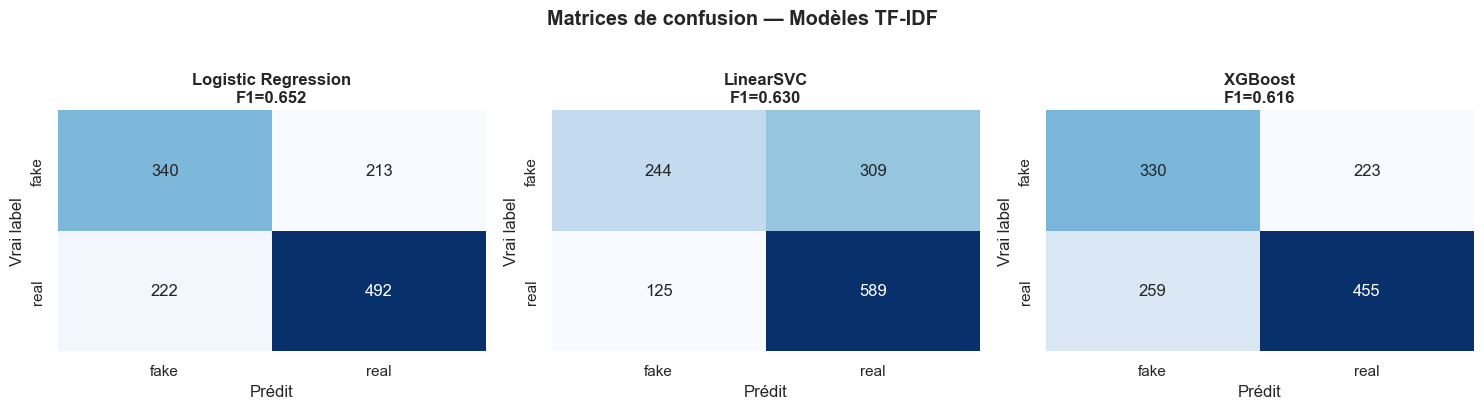

In [17]:
# Matrices de confusion
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['fake','real'],
                yticklabels=['fake','real'], cbar=False)
    ax.set_title(f'{name}\nF1={res["f1_macro"]:.3f}', fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Vrai label')
plt.suptitle('Matrices de confusion — Modèles TF-IDF', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Doc/BASE_01_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

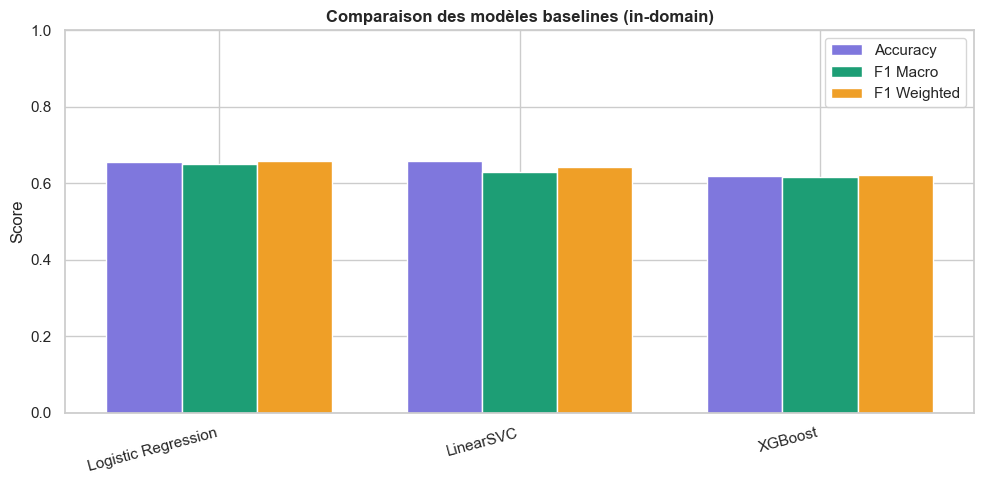

In [18]:
# Graphique comparatif
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp_df))
w = 0.25
ax.bar(x-w, comp_df['Accuracy'],    w, label='Accuracy',    color='#7F77DD')
ax.bar(x,   comp_df['F1 Macro'],    w, label='F1 Macro',    color='#1D9E75')
ax.bar(x+w, comp_df['F1 Weighted'], w, label='F1 Weighted', color='#EF9F27')
ax.set_xticks(x)
ax.set_xticklabels(comp_df['Modèle'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Comparaison des modèles baselines (in-domain)', fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig('../Doc/BASE_02_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

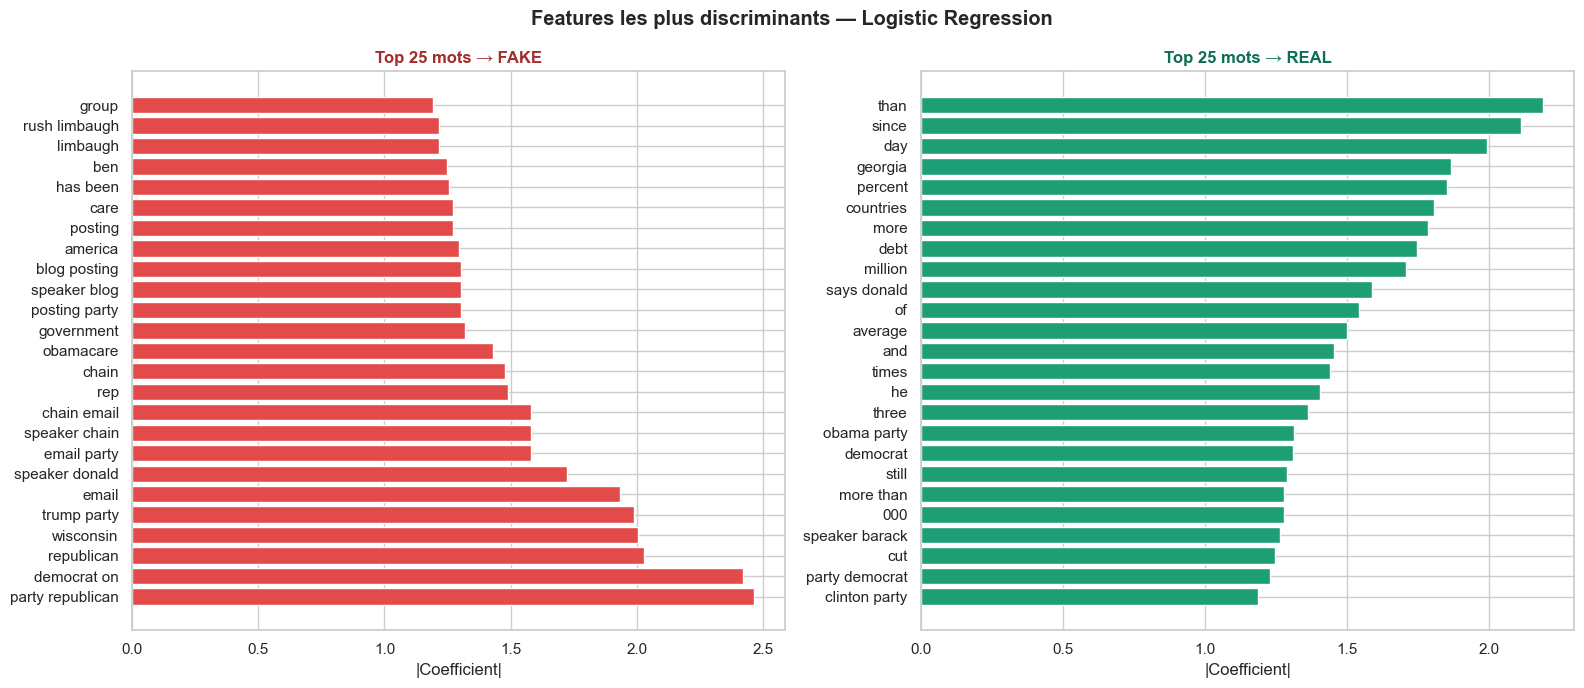

In [19]:
# Top features (Logistic Regression)
lr = results['Logistic Regression']['model']
feature_names = np.array(tfidf.get_feature_names_out())
coef  = lr.coef_[0]
top_n = 25

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top_fake = np.argsort(coef)[:top_n][::-1]
top_real = np.argsort(coef)[-top_n:][::-1]

axes[0].barh(feature_names[top_fake][::-1], np.abs(coef[top_fake][::-1]),
             color='#E24B4A', edgecolor='white')
axes[0].set_title(f'Top {top_n} mots → FAKE', fontweight='bold', color='#A32D2D')
axes[0].set_xlabel('|Coefficient|')

axes[1].barh(feature_names[top_real][::-1], np.abs(coef[top_real][::-1]),
             color='#1D9E75', edgecolor='white')
axes[1].set_title(f'Top {top_n} mots → REAL', fontweight='bold', color='#0F6E56')
axes[1].set_xlabel('|Coefficient|')

plt.suptitle('Features les plus discriminants — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.savefig('../Doc/BASE_03_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sauvegarde des modèles & métriques

In [20]:
# Sauvegarde modèles
joblib.dump(tfidf, '../data/modeles/tfidf_vectorizer.joblib')
joblib.dump(results['Logistic Regression']['model'], '../data/modeles/baseline_logreg.joblib')
joblib.dump(results['LinearSVC']['model'],           '../data/modeles/baseline_linearsvc.joblib')

# Sauvegarde métriques JSON
metrics = {n: {k: v for k, v in res.items() if k != 'model' and k != 'y_pred'}
           for n, res in results.items()}
with open('../data/modeles/baselines_metrics_test.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# Sauvegarde prédictions
test_df['pred_lr']  = results['Logistic Regression']['y_pred']
test_df['pred_svc'] = results['LinearSVC']['y_pred']
test_df['pred_xgb'] = results['XGBoost']['y_pred']
test_df.to_parquet('../data/traitees/liar_base_clean.parquet', index=False)

print(' Modèles sauvegardés dans data/modeles/')
print('   - tfidf_vectorizer.joblib')
print('   - baseline_logreg.joblib')
print('   - baseline_linearsvc.joblib')
print('   - baselines_metrics_test.json')
print(' Prédictions : data/traitees/liar_base_clean.parquet')
print('\n Modèles de base terminés → lancer Modeles_Avances.ipynb')

 Modèles sauvegardés dans data/modeles/
   - tfidf_vectorizer.joblib
   - baseline_logreg.joblib
   - baseline_linearsvc.joblib
   - baselines_metrics_test.json
 Prédictions : data/traitees/liar_base_clean.parquet

 Modèles de base terminés → lancer Modeles_Avances.ipynb
